#### Geopandas Homework - Anna Horton
Below is my analysis of the relationship between green space, Mardi Gras parade routes, and the wards of New Orleans, Louisiana. I want to understand if there is a relationship between the amount of green space in a ward and the prevalence of the parade route in that area. I will eventually also involve the demographics of the wards to identify if this is a trend that could be attributed to the demographic makeup of the neighborhoods. I specifically want to look at the biggest ward and the smallest ward and understand the differences between them. 

##### First step: upload and filter the data for just the attributes that I need

In [272]:
## uploading the packages
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## uploading the data itself
routes = gpd.read_file("Mardi_Gras_Routes_20261003.geojson")
greenspace = gpd.read_file("Open_Greenspace_20261003.geojson")
wards = gpd.read_file("Wards_20261003.geojson")

## making sure all of the projections are the same - getting some weird results further down
routes = routes.to_crs(epsg = 32615)
greenspace = greenspace.to_crs(epsg = 32615)
wards = wards.to_crs(epsg = 32615)

In [273]:
routes = routes[["parade", "location", "geometry"]]

## dropping the NaN values from the dataframe
routes.dropna(subset = ["parade"], how = "all", inplace = True)
routes.columns = ["name", "location", "geometry"]

In [274]:
greenspace = greenspace[["name", "geometry"]]
## dropping the NaN values from the dataframe
greenspace.dropna(subset = ["name"], how = "all", inplace = True)

In [275]:
wards = wards[["ward", "shape_area", "geometry"]]
wards.columns = ["name", "shape_area", "geometry"]

##### Plotting the various geometries to visualize the variables

<Axes: >

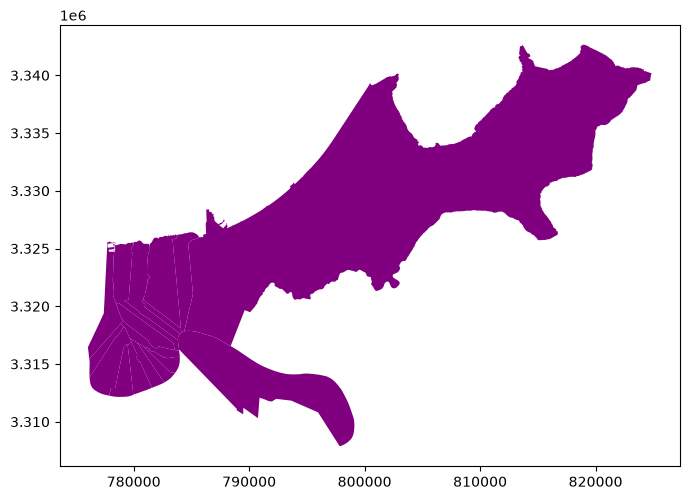

In [276]:
## plotting each of the earlier layers so that I can understand exactly where I am looking at
### plotting the ward boundaries
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="purple")


<Axes: >

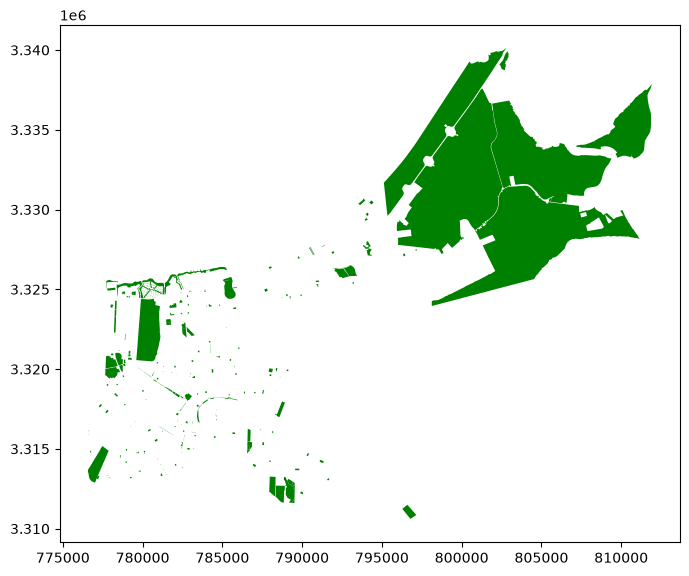

In [277]:
### plotting the greenspace boundaries
fig, ax = plt.subplots(figsize=(8,7))
greenspace.plot(ax=ax, color="green")

<Axes: >

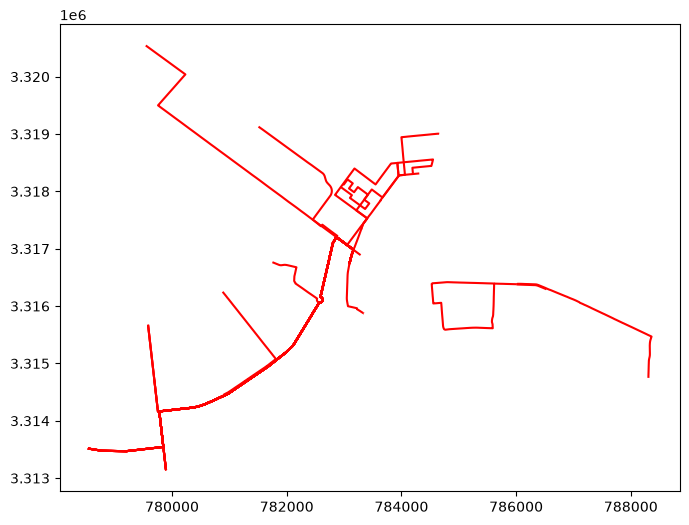

In [278]:
### plotting the parade routes
fig, ax = plt.subplots(figsize=(8,7))
routes.plot(ax=ax, color="red")


<Axes: >

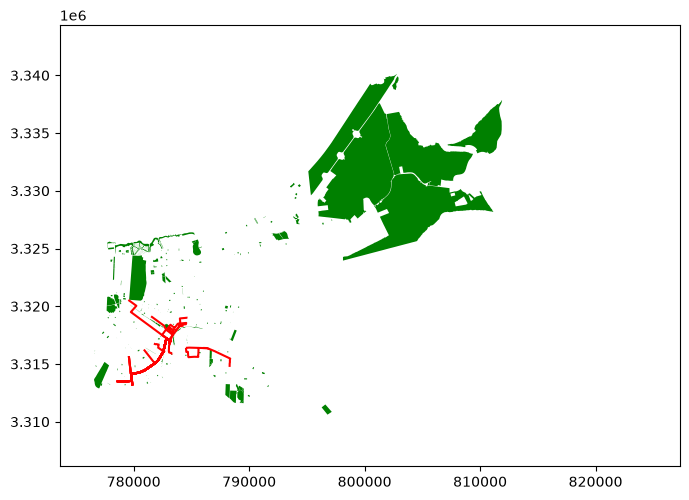

In [279]:
## plotting them all on top of each other to see if my analysis is doing anything helpful
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="white")
greenspace.plot(ax=ax, color="green")
routes.plot(ax=ax, color="red")

## visualized: there is some overlap of the parade routes and the ward boundaries, as well as some minimal overlap with the greenspace

#### Analysis!
##### Assessing first if there are intersections with the smallest and largest wards of New Orleans

In [280]:
## sorting the wards by the largest
wards = wards.sort_values("shape_area", ascending = True)

# selecting out the biggest ward and the smallest ward to compare
big_ward = wards.iloc[0]
big_ward

name                                                         14
shape_area                                   100139851.59973092
geometry      MULTIPOLYGON (((779520.5487918365 3317533.7189...
Name: 10, dtype: object

In [281]:
### finding out which parade routes intersect with the biggest ward boundaries
routes_inside_big = routes.geometry.intersects(big_ward.geometry)

## there are no routes that intersect the biggest ward, which means that I don't need to do any further analysis
## layer one

In [282]:
## finding out if any parade routes intersect the smallest ward (based on the information that I have now, I think that the answer is going to be yes)
small_ward = wards.iloc[-1]

## applying the intersection logic
routes_inside1 = routes.geometry.intersects(small_ward.geometry)
routes_inside1
print(routes_inside1.value_counts())

# there are a good amount of routes that intersect the small ward's geometry

True     31
False     5
Name: count, dtype: int64


#### Working on understanding the relationship of the downtown and uptown parades to the smallest ward

In [283]:
## differentiating between the uptown and downtown parades
uptown = routes[(routes["location"] == "Uptown")]
downtown = routes[(routes["location"] == "Downtown")]

## layer three
uptown_small = uptown.geometry.crosses(small_ward.geometry)
print(uptown_small.value_counts())
downtown_small = downtown.geometry.crosses(small_ward.geometry)
print(downtown_small.value_counts())

## there is a large amt of intersection with uptown and not a lot with downtown, only 2/4

True     28
False     2
Name: count, dtype: int64
True     2
False    2
Name: count, dtype: int64


#### Understanding the relationship of the greenspace to the uptown routes, considering that these are the routes that overlap with the smallest_ward in NOLA the most

In [284]:
## now I want to understand how big of a parade route these wards can accomodate
routes_buffer = uptown.buffer(distance = 500)
## adding the relationship between the greenspace and the buffer
greenspace_overflow = greenspace.geometry.overlaps(routes_buffer, align = True)
print(greenspace_overflow.value_counts())
# layer two
## the uptown routes, even with a 500 foot buffer, do not overlap with the greenspaces

False    287
Name: count, dtype: int64


#### Since I know that there is no overlap with the uptown routes with the greenspaces, even with a 500 foot buffer, I know that New Orleans is not using their greenspace to its full potential. 

#### Now I want to understand which wards they should expand into to maximize their use of greenspace. 